# **Task 1 — Data Loading & Exploration**

In [ ]:

import pandas as pd

# Load dataset
df = pd.read_csv("/content/housing.zip")

# Show first 10 rows
print(df.head(10))

# Shape
print(df.shape)

# Columns
print(df.columns)

# Missing values
print(df.isnull().sum())

      price   area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000   7420         4          2        3      yes        no       no   
1  12250000   8960         4          4        4      yes        no       no   
2  12250000   9960         3          2        2      yes        no      yes   
3  12215000   7500         4          2        2      yes        no      yes   
4  11410000   7420         4          1        2      yes       yes      yes   
5  10850000   7500         3          3        1      yes        no      yes   
6  10150000   8580         4          3        4      yes        no       no   
7  10150000  16200         5          3        2      yes        no       no   
8   9870000   8100         4          1        2      yes       yes      yes   
9   9800000   5750         3          2        4      yes       yes       no   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      

# **Task 2 — Data Cleaning**

In [ ]:
#TASK 2
#handle missing values (using fill)
df = df.fillna(df.mean(numeric_only=True))
#remove duplicates
df = df.drop_duplicates()
#convert text into numbers
df = pd.get_dummies(df, drop_first=True)

# **Task 3 — Model Building**

In [ ]:

#linear regression
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Features and target
X = df.drop("price", axis=1)
y = df["price"]

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train model
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predict
y_pred = lr.predict(X_test)



In [ ]:
#Evaluate using MAE,RMSE AND R2 SCORE
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 970043.4039201636
RMSE: 1324506.9600914386
R2 Score: 0.6529242642153184


In [ ]:
#Random Forest
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("RF R2:", r2_score(y_test, rf_pred))

RF R2: 0.5973456942154909


# **Task 4 — Visualization (Minimum 3 charts)**


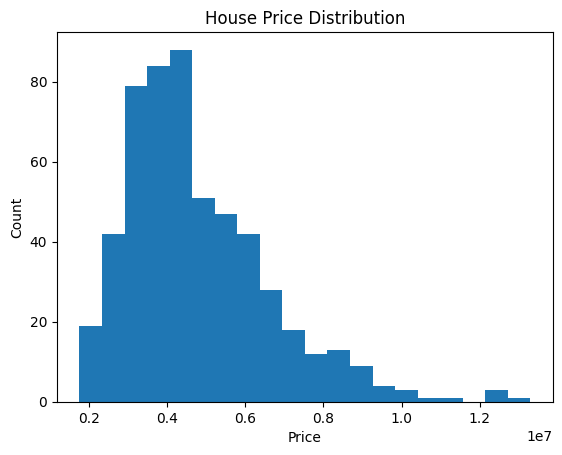

<Figure size 640x480 with 0 Axes>

In [ ]:

#Chart 1 Price Distribution
import matplotlib.pyplot as plt

plt.hist(df["price"], bins=20)
plt.title("House Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()
plt.savefig("chart1.png")

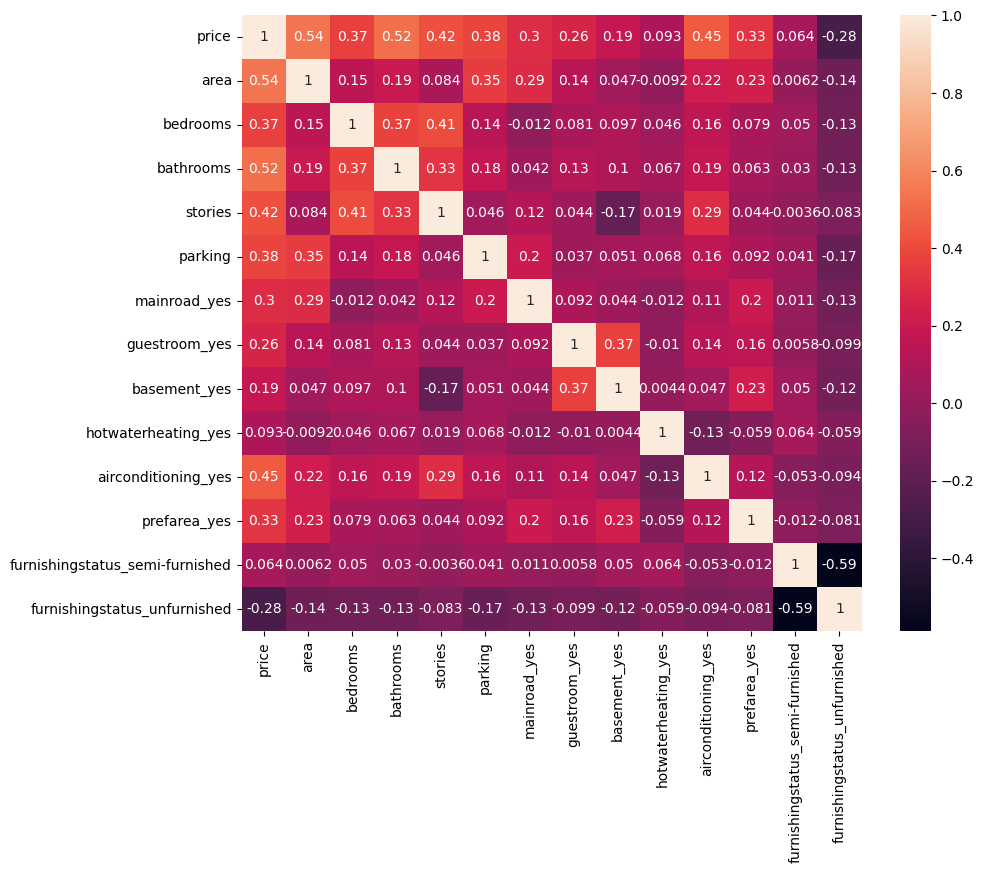

<Figure size 640x480 with 0 Axes>

In [ ]:
#Chart 2 CORRELATION HEATMAP
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.show()
plt.savefig("chart2.png")

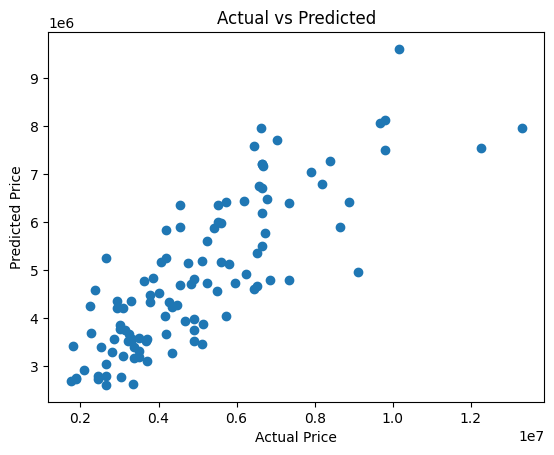

<Figure size 640x480 with 0 Axes>

In [ ]:
#Chart 3 Actual vs Predicted
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()
plt.savefig("chart3.png")

# **Task 5 — Insights & Summary**
After analyzing the housing dataset, it was found that area, number of bedrooms, bathrooms, stories, parking, and furnishing status are the most important factors affecting house prices, with larger and better-equipped houses generally having higher values. The machine learning models showed good prediction performance, with Random Forest being more accurate than Linear Regression due to its ability to capture complex relationships between features. A surprising finding was that some smaller houses had very high prices, indicating that factors such as furnishing and other property characteristics also play a significant role. Based on these findings, real estate businesses should focus on improving property facilities, furnishing quality, and parking availability while using machine learning models to make more accurate pricing and investment decisions.
